Cell-free UE pozisyonlari yuklendi: (16, 3)
Shape of a: (16, 1, 1, 1, 16, 29, 14)
Shape of tau: (16, 1, 1, 29)
Shape of h_freq: (16, 1, 1, 1, 16, 14, 128)
Uretilen Grid Boyutu: (100, 1, 1, 14, 128)

EbNo = 5.0 dB icin 16 UE taraniyor (her biri 100 batch)...
UE  0 | BER: 0.498619
UE  1 | BER: 0.498619
UE  2 | BER: 0.498619
UE  3 | BER: 0.498619
UE  4 | BER: 0.498619
UE  5 | BER: 0.000000
UE  6 | BER: 0.000000
UE  7 | BER: 0.498619
UE  8 | BER: 0.498619
UE  9 | BER: 0.000000
UE 10 | BER: 0.000000
UE 11 | BER: 0.498619
UE 12 | BER: 0.498619
UE 13 | BER: 0.498619
UE 14 | BER: 0.498619
UE 15 | BER: 0.498619

--- PER-LOCATION ANALIZI TAMAMLANDI ---

UE No    | Aktif Anten  | En Guclu Anten  | Max Guc     
------------------------------------------------------------
UE 0     | 0            | Anten 0        | 0.0000
UE 1     | 0            | Anten 0        | 0.0000
UE 2     | 0            | Anten 0        | 0.0000
UE 3     | 0            | Anten 0        | 0.0000
UE 4     | 0            | Ante

C:\Users\yilmaz.meryem\AppData\Local\Temp\ipykernel_9424\2924774599.py:309: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


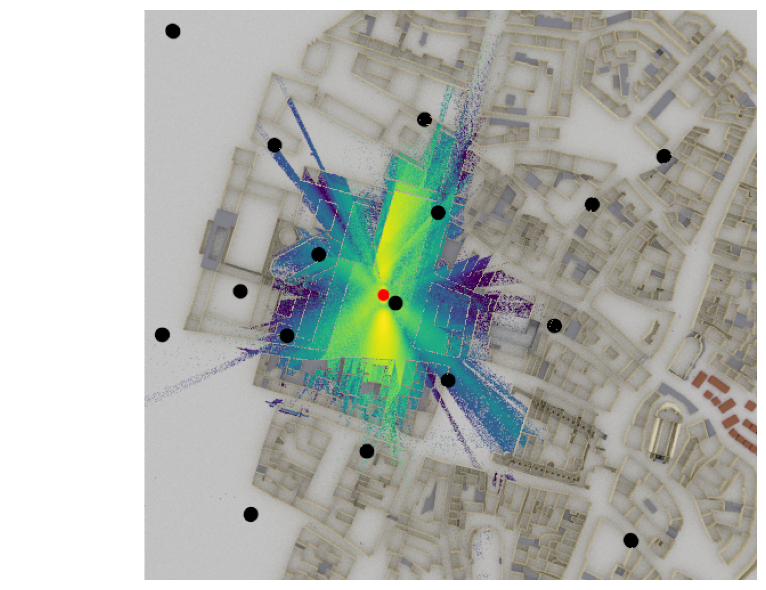

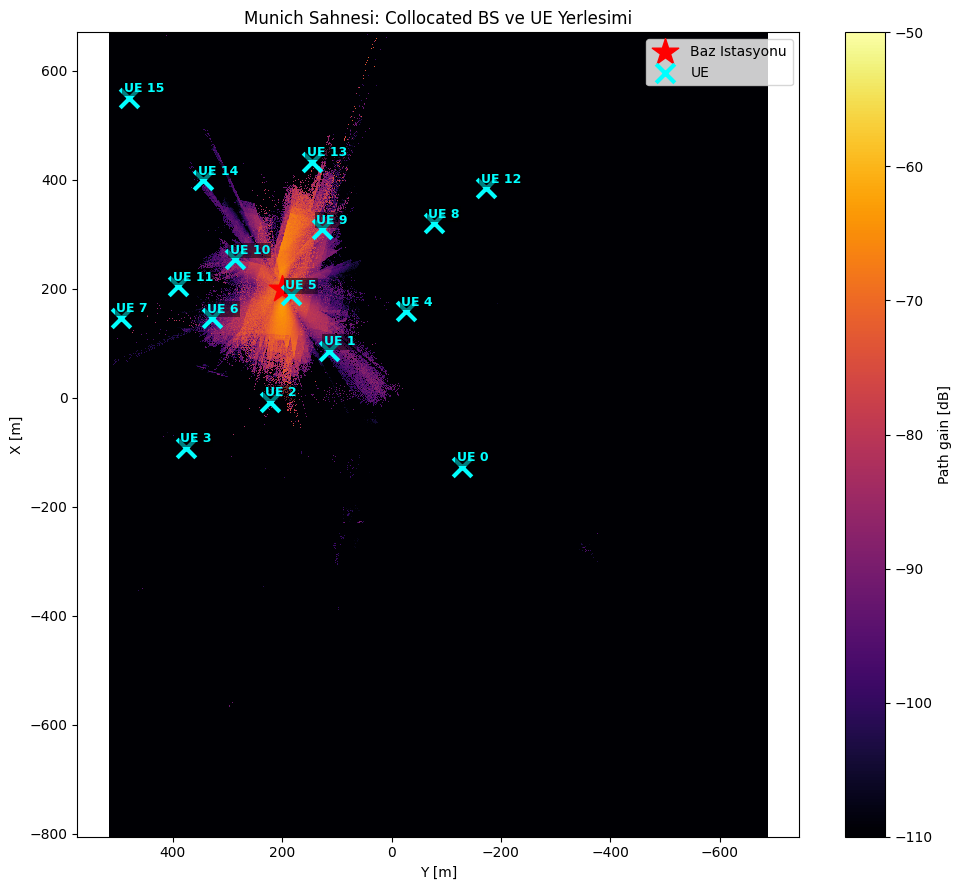

In [1]:

# Collocated Massive MIMO — Referans (Baseline) Senaryosu
# Merkezde tek bir baz istasyonu (4x4 = 16 antenli) bulunur ve
# CELL-FREE yerlesimindeki UE pozisyonlarini (ue_positions.npy) kullanir.
# Boylece dagitik (cell-free) ile merkezi (collocated) mimari ayni UE
# konumlari uzerinde karsilastirilabilir. Precoding: MRT.
#
# NOT: Bu betik calismadan once ana cell-free betigi calistirilmis ve
# ue_positions.npy olusturulmus olmalidir.


import os
# GPU varsa onu kullan, yoksa "" yazilirsa CPU'ya duser; ortam degiskeni ile secilir.
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0  # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
        print("Installing Sionna and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna")
        os.kill(os.getpid(), 5)
    else:
        raise e

# Tek GPU kullan ve sadece gerektigi kadar bellek ayir
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
tf.get_logger().setLevel('ERROR')

import numpy as np
import matplotlib.pyplot as plt
from sionna.phy.mapping import BinarySource, Constellation, Mapper, Demapper
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel
from sionna.phy.utils import ebnodb2no, compute_ber
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray, \
                      PathSolver, RadioMapSolver

# Tekrarlanabilirlik icin tohum
sionna.phy.config.seed = 42

no_preview = True






# SISTEM PARAMETRELERI

subcarrier_spacing = 30e3   # Hz
num_time_steps = 14         # bir slottaki OFDM sembol sayisi
fft_size = 128              # OFDM subcarrier sayisi
num_bits_per_symbol = 2     # QPSK
num_ofdm_symbols = 14
batch_size_payload = 100    # Monte Carlo paket sayisi

scene = load_scene(sionna.rt.scene.munich)

# ============================================================
# BAZ ISTASYONU (tek tx, 4x4 = 16 antenli dizi)
# ============================================================
scene.tx_array = PlanarArray(num_rows=4,            # dikeyde 4 anten
                             num_cols=4,            # yatayda 4 anten -> toplam 16 anten
                             vertical_spacing=0.5,  # elemanlar arasi mesafe (yarim dalga boyu)
                             horizontal_spacing=0.5,
                             pattern="dipole",      # dipol: 360 derece omni-yonlu patern
                             polarization="V")

bs_position = [200, 200, 10]   # baz istasyonu sahnenin merkezinde

if "base_station" in scene.transmitters:   # ilk calistirmada hata vermesin
    scene.remove("base_station")
# Hiz vektoru verilmedi -> tx kaynakli Doppler kaymasi olmaz.
tx = Transmitter(name="base_station",
                 position=bs_position,
                 display_radius=8.,
                 color=(1, 0, 0))
scene.add(tx)

bird_cam = Camera(position=[200, 200, 1200], look_at=[200, 200, 0])

max_depth = 5   # radio map icin isinin maksimum yansima sayisi

# ============================================================
# RADIO MAP
# ============================================================
rm_solver = RadioMapSolver()
# cell_size: izgara cozunurlugu. samples_per_tx: BS'ten firlatilan isin sayisi (10 milyon).
rm = rm_solver(scene,
               max_depth=max_depth,
               cell_size=(1., 1.),
               samples_per_tx=10**7)







# UE POZISYONLARI — CELL-FREE YERLESIMINI KULLAN

# Cell-free betigi tarafindan kaydedilmis 16 UE konumunu yukle.
if not os.path.exists("ue_positions.npy"):
    raise FileNotFoundError(
        "ue_positions.npy bulunamadi. Once ana cell-free betigini calistirip "
        "UE pozisyonlarini kaydetmelisin."
    )
positions = np.load("ue_positions.npy")
print(f"Cell-free UE pozisyonlari yuklendi: {positions.shape}")

scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="V")

for i in range(len(positions)):
    rx_name = f"rx-{i}"
    if rx_name in scene.receivers:
        scene.remove(rx_name)
    rx = Receiver(name=rx_name,
                  position=positions[i],
                  orientation=[0, 0, 0],
                  display_radius=10.,
                  color=(0, 0, 0))
    scene.add(rx)

if no_preview:
    scene.render(camera=bird_cam, radio_map=rm, rm_vmin=-110, clip_at=12.)
else:
    scene.preview(radio_map=rm, rm_vmin=-110, clip_at=12.)








# KANAL HESABI (CIR -> OFDM frekans cevabi)

p_solver = PathSolver()
max_depth = 3   # path solver icin yansima sayisi
# Sahnedeki tum TX-RX ciftleri arasindaki yollari bulur (her vericiden en guclu 1000 yol).
paths = p_solver(scene, max_depth=max_depth, max_num_paths_per_src=10**3)

# a: kompleks genlik (gecikme -> faz). tau: gecikme (zamandan bagimsiz).
a, tau = paths.cir(sampling_frequency=subcarrier_spacing,
                   num_time_steps=num_time_steps,
                   out_type='numpy')

a = np.expand_dims(a, axis=0)
tau = np.expand_dims(tau, axis=0)

# num_rx ve batch boyutlarini yer degistir (her adimda bastaki boyuttan bir UE secebilmek icin)
a = np.transpose(a, [1, 0, 2, 3, 4, 5, 6])
tau = np.transpose(tau, [1, 0, 2, 3])

print("Shape of a:", a.shape)
print("Shape of tau:", tau.shape)

frequencies = subcarrier_frequencies(fft_size, subcarrier_spacing)
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)
print("Shape of h_freq:", h_freq.shape)
# h_freq[UE, num_rx, num_rx_ant, num_tx, BS_anten, time, freq]
# h_freq[loc_idx, 0, 0, 0, :, :, :] -> secilen UE'nin 16 BS anteni kanali: [16, 14, 128]






# ORTAK NESNELER VE VERI URETIMI

constellation = Constellation("qam", num_bits_per_symbol=2)
binary_source = BinarySource()
mapper = Mapper(constellation=constellation)
new_demapper = Demapper(demapping_method="app", constellation=constellation)

rg = ResourceGrid(num_ofdm_symbols=num_ofdm_symbols,
                  fft_size=fft_size,
                  subcarrier_spacing=30e3,
                  num_tx=1,
                  num_streams_per_tx=1,
                  pilot_pattern=None,
                  num_guard_carriers=[0, 0],
                  dc_null=False)

rg_mapper = ResourceGridMapper(rg)
bits = binary_source([batch_size_payload, 1, 1, rg.num_data_symbols * num_bits_per_symbol])
x = mapper(bits)
x_rg = rg_mapper(x)
x_signal = tf.reshape(x_rg, [batch_size_payload, 14, 128])
print(f"Uretilen Grid Boyutu: {x_rg.shape}")









# 1) SABIT SNR'da HER UE icin MRT BER (per-location)

ebno_db_fixed = 5.0
no_val = ebnodb2no(ebno_db=ebno_db_fixed, num_bits_per_symbol=num_bits_per_symbol, coderate=1.0)

ber_list_per_loc = []
print(f"\nEbNo = {ebno_db_fixed} dB icin {len(positions)} UE taraniyor (her biri {batch_size_payload} batch)...")

for loc_idx in range(len(positions)):
    # Bu UE'nin 16 BS anteni kanali: [16, 14, 128]
    h_ue_per_loc = tf.cast(h_freq[loc_idx, 0, 0, 0, :, :, :], tf.complex64)

    # MRT precoder (16 BS anteni uzerinden): w = conj(h), birim norma normalize
    w_mrt_per_loc = tf.math.conj(h_ue_per_loc)
    w_mrt_per_loc = w_mrt_per_loc / tf.cast(tf.norm(w_mrt_per_loc, axis=0, keepdims=True) + 1e-9, tf.complex64)

    x_signal_exp_per_loc = tf.expand_dims(x_signal, axis=1)        # [batch, 1, 14, 128]
    x_precoded_per_loc = w_mrt_per_loc * x_signal_exp_per_loc      # [batch, 16, 14, 128]

    # Antenler uzerinden birlesme (beamforming) -> UE anteninde toplanan sinyal
    y_received_per_loc = tf.reduce_sum(h_ue_per_loc * x_precoded_per_loc, axis=1)  # [batch, 14, 128]

    noise_std_per_loc = tf.sqrt(no_val / 2)
    noise_per_loc = tf.complex(tf.random.normal(tf.shape(y_received_per_loc), stddev=noise_std_per_loc),
                               tf.random.normal(tf.shape(y_received_per_loc), stddev=noise_std_per_loc))
    y_noisy_per_loc = y_received_per_loc + noise_per_loc

    g_eff_per_loc = tf.reduce_sum(h_ue_per_loc * w_mrt_per_loc, axis=0)
    x_hat_per_loc = y_noisy_per_loc / tf.cast(g_eff_per_loc + 1e-12, tf.complex64)

    x_hat_flat_per_loc = tf.reshape(x_hat_per_loc, [batch_size_payload, -1])
    llr = new_demapper(x_hat_flat_per_loc, tf.cast(no_val, tf.float32))
    bits_hat = tf.cast(llr > 0, tf.float32)
    bits_hat_final = tf.reshape(bits_hat, bits.shape)

    current_ber = compute_ber(bits, bits_hat_final).numpy()
    ber_list_per_loc.append(current_ber)
    print(f"UE {loc_idx:2d} | BER: {current_ber:.6f}")

print("\n--- PER-LOCATION ANALIZI TAMAMLANDI ---")








# 2) HER UE icin BS anten guc dagilimi (analiz)

print(f"\n{'UE No':<8} | {'Aktif Anten':<12} | {'En Guclu Anten':<15} | {'Max Guc':<12}")
print("-" * 60)
for u_idx in range(len(positions)):
    ant_powers = np.array([np.sum(np.abs(h_freq[u_idx, 0, 0, 0, a_idx, :, :])) for a_idx in range(16)])
    active_ant = np.sum(ant_powers > 1.0)
    max_ant = np.argmax(ant_powers)
    print(f"UE {u_idx:<5} | {active_ant:<12} | Anten {max_ant:<8} | {np.max(ant_powers):.4f}")







# 3) PATH GAIN HARITASI + BS ve UE konumlari

def to_numpy(x):
    return x.numpy() if hasattr(x, "numpy") else np.asarray(x)

pg = to_numpy(rm.path_gain)
pg_db = 10 * np.log10(np.max(pg, axis=0) + 1e-30)
centers = to_numpy(rm.cell_centers)
x_map = centers[:, :, 1]
y_map = centers[:, :, 0]

plt.figure(figsize=(10, 9))
plt.pcolormesh(x_map, y_map, pg_db, shading="auto", cmap="inferno", vmin=-110, vmax=-50)
plt.colorbar(label="Path gain [dB]")

# Tek baz istasyonu
bs_xy = np.array(bs_position)[:2]
plt.scatter(bs_xy[1], bs_xy[0], marker="*", s=400, color="red", zorder=4, label="Baz Istasyonu")

# UE'ler
ue_xy = to_numpy(positions).reshape(-1, 3)[:, :2]
plt.scatter(ue_xy[:, 1], ue_xy[:, 0], marker="x", s=180, linewidths=3, color="cyan", zorder=4, label="UE")
for i, (x_ue, y_ue) in enumerate(ue_xy):
    plt.text(y_ue + 10, x_ue + 10, f"UE {i}", color="cyan", fontsize=9, fontweight="bold", zorder=5,
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

plt.xlabel("Y [m]")
plt.ylabel("X [m]")
plt.title("Munich Sahnesi: Collocated BS ve UE Yerlesimi")
plt.xlim(400, 0)
plt.ylim(0, 400)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()



